In [1]:
import sys
sys.path.insert(0, '../../')

from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock
from panel_exp.design.design_metrics import imbalance
import copy

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import RidgeCV, Ridge
from panel_exp.methods.scm import SyntheticControl, AugSynth 

from panel_exp.inference import conformal
import pandas as pd
import numpy as np
from panel_exp.impact import ImpactAnalyzer
from panel_exp.inference.unit_jackknife import unit_jk, unit_jackknife
from panel_exp.inference.conformal import conformal

from scipy.optimize import minimize
from sklearn.linear_model import RidgeCV, Ridge
import warnings
from panel_exp.methods.tbr import TBR, TBRRidge
import cvxpy as cp
  
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
from panel_exp.design import power

import multiprocessing

proc = multiprocessing.cpu_count()

# Power Function Comparison to Meta

In [2]:
# kansas , smoking
ds = 'meta_geo'

if ds == 'kansas':
    long_df = pd.read_csv('../data/kansas_parsed.csv')
    long_df = long_df[long_df.year_qtr < 2012]
    pds = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp")
    wide_df = pds.wide_data
    #pds = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas", "Illinois"], [2012, 2012])

if ds == 'smoking':
    long_df = pd.read_csv('../data/smoking.csv')
    long_df = long_df[long_df.year < 1988]
    long_df.columns = ['unnamed', 'unit', 'time_unit', 'y',  'lnincome','beer','age15to24','retprice']
    pds = long_df_to_paneldataset(long_df, "time_unit", "unit", "y" ) 
    wide_df = pds.wide_data

if ds == 'meta_geo':
    long_df = pd.read_csv('../data/meta_geo.csv')
    long_df = long_df[long_df.time < 91]
    wide_df = pd.pivot_table(long_df, index='location', columns='time', values='Y')
    pds = PanelDataset(wide_df  )
    #pds = PanelDataset(wide_df, [TimePeriod(start =91, end=105) ], ["portland" ])


In [3]:

pds



        Panel Dataset Summary
        ---------------------
        Number of time points: 90
        Number of units: 40
        Number of treated units: 0
        Treated units: None
        Treated periods: None
        

In [4]:
'''
cr = CompleteRandomization(treatment_probability=0.5)
paneldata_post_assignment = cr.assign(pds)
paneldata_post_assignment.treated_units
'''

'\ncr = CompleteRandomization(treatment_probability=0.5)\npaneldata_post_assignment = cr.assign(pds)\npaneldata_post_assignment.treated_units\n'

In [5]:
# Aggregate test. I'll need to add support for multiple treated modelled individually
# Pre-Aggregate

#control_units = pd.DataFrame(wide_df.loc[paneldata_post_assignment.control_units] ).T
#treated_units = pd.DataFrame(wide_df.loc[paneldata_post_assignment.treated_units].mean(axis=0), columns=['treated'])
#wide_agg = pd.concat([treated_units, control_units], axis=1)

control_units = pd.DataFrame(wide_df.loc[[unit for unit in pds.units if unit not in ['chicago', 'cincinnati', 'houston', 'portland', 'honolulu']]] ).T
treated_units = pd.DataFrame(wide_df.loc[['chicago', 'cincinnati', 'houston', 'portland']].mean(axis=0), columns=['treated'])
wide_agg = pd.concat([treated_units, control_units], axis=1)

end = wide_df.columns[-1]
L = len(wide_df.columns)
test_length = 14

In [6]:
panel_data = PanelDataset(wide_agg.T, treated_units = ['treated'], treated_periods=[TimePeriod(start=L-test_length)])
#panel_data

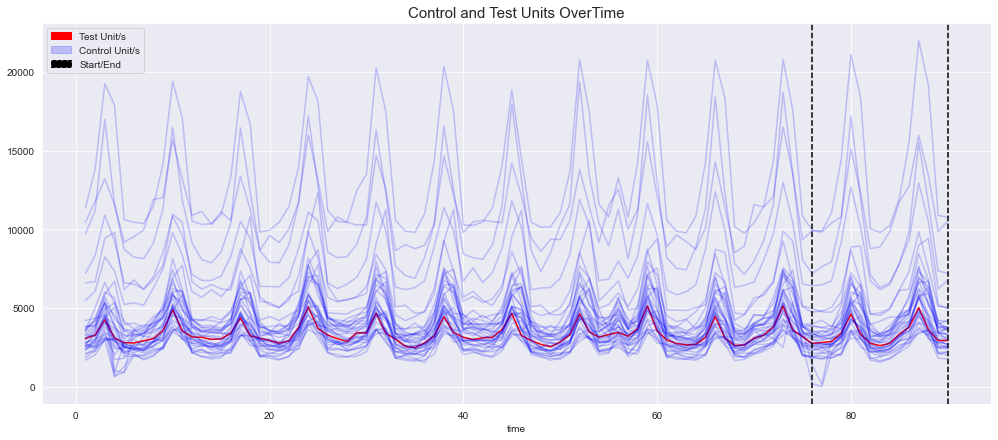

In [7]:
panel_data.plot()

In [8]:
pa = power.PowerAnalysis(panel_data
                         , TBRRidge
                         , 'Kfold'
                         , test_length
                         , mx_effect=.25 
                         , n_jobs=10)


In [9]:
pa.run_analysis()


  0%|          | 0/90 [00:00<?, ?it/s]

100%|██████████| 90/90 [01:47<00:00,  1.19s/it]


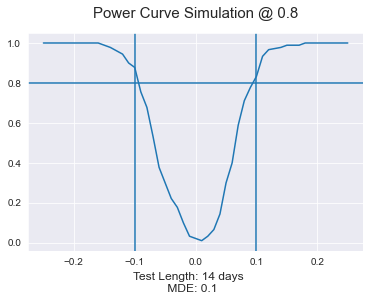

In [10]:
pa.plot_power_curve('percent_effect')

In [11]:
pa.summary()

,Parameters
Model,TBRRidge
Inference,Kfold
Test Length,14
Number of Simulations,4410
,Statistics
MDE Percent,-0.1
MDE KPI,-4873.134259
Power,0.8
Type 1 Error Rate,0.044444
